In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point

In [4]:
dirindices='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'
#dirindices

In [5]:
dirindices_new='/nf1/predict/AWH017_ABID_ASPECT/equalwgts_merged_data/anomaly/indices/'
#dirindices_new

In [6]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
#dirfig

# ERA5 index

In [7]:
era5_index_1=xr.open_dataset(dirindices+'era5_anom_obsmaap_freqts_index_1.nc')


# EOBS index

In [8]:
eobs_index_1=xr.open_dataset(dirindices+'eobs_ffd_marapr.nc')


# Equally merged dataset

In [9]:
merge0_index_1=xr.open_dataset(dirindices_new+'merge0_index.nc')


In [10]:
merge1_index_1=xr.open_dataset(dirindices_new+'merge1_index.nc')


In [11]:
merge2_index_1=xr.open_dataset(dirindices_new+'merge2_index.nc')


In [12]:
merge3_index_1=xr.open_dataset(dirindices_new+'merge3_index.nc')


In [13]:
merge4_index_1=xr.open_dataset(dirindices_new+'merge4_index.nc')


In [14]:
merge5_index_1=xr.open_dataset(dirindices_new+'merge5_index.nc')


In [15]:
merge6_index_1=xr.open_dataset(dirindices_new+'merge6_index.nc')


In [16]:
merge7_index_1=xr.open_dataset(dirindices_new+'merge7_index.nc')


# Individual start date

In [17]:


masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
masktopo

maskfo_1=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<80),drop=True)
maskfo_1

<xarray.Dataset> Size: 1MB
Dimensions:    (latitude: 219, longitude: 1437)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 876B 79.75 79.5 79.25 ... 25.75 25.5 25.25
    time       datetime64[ns] 8B 1981-01-01T01:00:00
Data variables:
    topo       (latitude, longitude) float32 1MB nan nan nan nan ... 1.0 1.0 1.0

In [18]:
novy2_index_1=xr.open_dataset(dirindices+'nov_y2_anom_mem_index.nc')
novy2_index_1=novy2_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#novy2_index_1

In [19]:
may_index_1=xr.open_dataset(dirindices+'mayY1_anom_mem_index.nc')
may_index_1=may_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#may_index_1

In [20]:
aug_index_1=xr.open_dataset(dirindices+'aug_anom_mem_index.nc')
aug_index_1=aug_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#aug_index_1

In [26]:
dirdata='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/'
dirdata

oct_fcst_1=xr.open_dataset(dirdata+'anomaly_forecast_oct.nc')
oct_fcst_1=oct_fcst_1.where((oct_fcst_1.latitude>25)&(oct_fcst_1.latitude<80),drop=True)
#oct_fcst_1

#oct_index_1

In [27]:
nov_index_1=xr.open_dataset(dirindices+'nov_anom_mem_index.nc')
nov_index_1=nov_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#nov_index_1

In [28]:
dec_index_1=xr.open_dataset(dirindices+'dec_anom_mem_index.nc')
dec_index_1=dec_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#dec_index_1

In [29]:
jan_index_1=xr.open_dataset(dirindices+'jan_anom_mem_index.nc')
jan_index_1=jan_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#jan_index_1

In [30]:
feb_index_1=xr.open_dataset(dirindices+'feb_anom_mem_index.nc')
feb_index_1=feb_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#feb_index_1

In [31]:
mar_index_1=xr.open_dataset(dirindices+'mar_anom_mem_index.nc')
mar_index_1=mar_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#mar_index_1

In [32]:
may_y2_index_1=xr.open_dataset(dirindices+'may_y2_anom_mem_index.nc')
may_y2_index_1=may_y2_index_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#may_y2_index_1

# old merge including jan

In [34]:
old_merge1=xr.open_dataset(dirindices+'anom_merge1_index.nc')
old_merge1=old_merge1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#old_merge1

In [35]:
old_merge2=xr.open_dataset(dirindices+'anom_merge2_index.nc')
old_merge2=old_merge2.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge2

<xarray.Dataset> Size: 10kB
Dimensions:  (member: 55, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 440B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 9kB ...

In [36]:
old_merge3=xr.open_dataset(dirindices+'anom_merge3_index.nc')
old_merge3=old_merge3.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge3

<xarray.Dataset> Size: 14kB
Dimensions:  (member: 80, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 640B 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 13kB ...

In [37]:
old_merge4=xr.open_dataset(dirindices+'anom_merge4_index.nc')
old_merge4=old_merge4.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge4

<xarray.Dataset> Size: 22kB
Dimensions:  (member: 131, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 1kB 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 21kB ...

In [38]:
old_merge5=xr.open_dataset(dirindices+'anom_merge5_index.nc')
old_merge5=old_merge5.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge5

<xarray.Dataset> Size: 27kB
Dimensions:  (member: 156, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 1kB 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 25kB ...

In [39]:
old_merge6=xr.open_dataset(dirindices+'anom_merge61_index.nc')
old_merge6=old_merge6.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge6

<xarray.Dataset> Size: 31kB
Dimensions:  (member: 181, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 1kB 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 29kB ...

In [40]:
old_merge7=xr.open_dataset(dirindices+'anom_merge611_index.nc')
old_merge7=old_merge7.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
old_merge7

<xarray.Dataset> Size: 39kB
Dimensions:  (member: 232, time: 40)
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30
  * member   (member) float64 2kB 0.0 10.0 11.0 12.0 13.0 ... 6.0 7.0 8.0 9.0
Data variables:
    fd       (member, time) float32 37kB ...

# Here calculation begins

In [41]:
oct_anom_memindex=np.zeros((25,40),np.float32)

for i in arange(0,25):

    mem_tmp_0=Adtools.data_sub(oct_fcst_1.fd[0:40,i,:,:]*maskfo_1.topo,0,3.5,41,43)
    oct_anom_memindex[i,:]=mem_tmp_0.weighted(np.cos(np.deg2rad(mem_tmp_0.latitude))).mean(('longitude','latitude'))


In [42]:
#oct_anom_memindex.shape[0]

In [43]:
anom_ensmean_index_oct=np.mean(oct_anom_memindex,axis = 0)
#anom_ensmean_index_oct

In [44]:
#based on 51 members
anom_ensmean_index_nov=np.mean(nov_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_nov.shape


anom_ensmean_index_dec=np.mean(dec_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_dec.shape

anom_ensmean_index_jan=np.mean(jan_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_jan.shape

#based on 51 members
anom_ensmean_index_feb=np.mean(feb_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_feb.shape

anom_ensmean_index_mar=np.mean(mar_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_mar.shape


anom_ensmean_index_may=np.mean(may_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_may.shape

anom_ensmean_index_aug=np.mean(aug_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_aug.shape


#based on 24 month forecast


anom_ensmean_index_may_y2=np.mean(may_y2_index_1.fd[:,:].values,axis = 0)
anom_ensmean_index_may_y2


anom_ensmean_index_nov_y2=np.mean(novy2_index_1.fd[:,:].values,axis = 0)
#anom_ensmean_index_nov_y2

In [45]:
from scipy.stats import bootstrap
rng = np.random.default_rng()

In [46]:
def corr(x,  y):
    return stats.pearsonr(x,y)[0]

In [47]:
obs=era5_index_1.fd.values
#obs

In [48]:
resoct = bootstrap((obs,  anom_ensmean_index_oct), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
#print(resoct.confidence_interval)

In [49]:
#skilloct=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_oct)
#skilloct
#anom_freq.fd
skilloct=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_oct)
skilloct

skillnov=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_nov)
skillnov

skilldec=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_dec)
skilldec

skilljan=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_jan)
skilljan

skillfeb=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_feb)
skillfeb

skillmar=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_mar)
skillmar

skillmay=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_may)
skillmay

skillaug=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_aug)
skillaug

skillmay_y2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_may_y2)
skillmay_y2


skillnov_y2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_nov_y2)
#skillnov_y2

In [50]:
value=skilloct.rvalue
#value

In [53]:
skillmatrix_maap_n=[skillmay_y2.rvalue,skillnov_y2.rvalue,skillmay.rvalue,skillaug.rvalue, skilloct.rvalue, skillnov.rvalue,skilldec.rvalue, skilljan.rvalue, skillfeb.rvalue, skillmar.rvalue]
#skillmatrix_maap_n



#skillmatrix_maap_err=[skillmay_y2.stderr,skillnov_y2.stderr,skillmay.stderr,skillaug.stderr, skilloct.stderr, skillnov.stderr,skilldec.stderr, skilljan.stderr,skillfeb.stderr, skillmar.stderr]
#skillmatrix_maap_err, skillmatrix_maap_n

In [54]:
oct_fcst_1.fd.shape[1]

25

In [55]:
ensize=np.array([may_y2_index_1.fd[:,0].shape,novy2_index_1.fd[:,0].shape,may_index_1.fd[:,0].shape,aug_index_1.fd[:,0].shape,oct_index_1.fd[:,0].shape,nov_index_1.fd[:,0].shape,dec_index_1.fd[:,0].shape,jan_index_1.fd[:,0].shape,feb_index_1.fd[:,0].shape,mar_index_1.fd[:,0].shape])
ensize[:,0]

array([25, 25, 15, 15, 25, 51, 25, 25, 51, 25])

In [56]:
resnovY2 = bootstrap((obs, anom_ensmean_index_nov_y2), corr, paired=True, n_resamples=10000,method='basic',vectorized=False,confidence_level=0.95)
print(resnovY2.confidence_interval)

ConfidenceInterval(low=-0.02051928341388698, high=0.5429603578522801)


In [57]:
resmayY2 = bootstrap((obs,  anom_ensmean_index_may_y2), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resmayY2.confidence_interval)

ConfidenceInterval(low=-0.04902751147747031, high=0.4571803363040089)


In [58]:
resmay = bootstrap((obs,  anom_ensmean_index_may[0:40]), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resmay.confidence_interval)

ConfidenceInterval(low=0.009816849231719993, high=0.6065715488046407)


In [59]:
resaug = bootstrap((obs,  anom_ensmean_index_aug), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resaug.confidence_interval)

ConfidenceInterval(low=-0.11333581209182736, high=0.47565599009394643)


In [60]:
resnov = bootstrap((obs,  anom_ensmean_index_nov[0:40]), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resnov.confidence_interval)

ConfidenceInterval(low=-0.08348726034164422, high=0.5714176123961806)


In [61]:
resdec = bootstrap((obs,  anom_ensmean_index_dec), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resdec.confidence_interval)

ConfidenceInterval(low=-0.16830542013049088, high=0.44955928772687903)


In [62]:
resjan = bootstrap((obs,  anom_ensmean_index_jan), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resjan.confidence_interval)

ConfidenceInterval(low=-0.4059890035539865, high=0.1497985690832137)


In [63]:
resfeb = bootstrap((obs,  anom_ensmean_index_feb[0:40]), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resfeb.confidence_interval)

ConfidenceInterval(low=-0.1666882812976837, high=0.35925069227814665)


In [64]:
resmar = bootstrap((obs,  anom_ensmean_index_mar[0:40]), corr, paired=True, n_resamples=10000, method='basic', vectorized=False,confidence_level=0.95)
print(resmar.confidence_interval)

ConfidenceInterval(low=0.6093706458806992, high=0.9997334375977516)


In [74]:
skill_lbnd_1=[resmayY2.confidence_interval.low,resnovY2.confidence_interval.low,resmay.confidence_interval.low,resaug.confidence_interval.low,resoct.confidence_interval.low,resnov.confidence_interval.low,resdec.confidence_interval.low,resjan.confidence_interval.low,resfeb.confidence_interval.low,resmar.confidence_interval.low]
#skill_lbnd_1

In [206]:
skill_upbnd_1=[resmayY2.confidence_interval.high,resnovY2.confidence_interval.high,resmay.confidence_interval.high,resaug.confidence_interval.high,resoct.confidence_interval.high,resnov.confidence_interval.high,resdec.confidence_interval.high,resjan.confidence_interval.high,resfeb.confidence_interval.high,resmar.confidence_interval.high]
#skill_upbnd_1

In [209]:
#skill_upbnd_1

In [68]:
#leadtime2
#skillmatrix_maap_n

# skill assessment with EOBS

In [69]:
skilloct_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_oct)

skillnov_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_nov)

skilldec_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_dec)

skilljan_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_jan)

skillfeb_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_feb)

skillmar_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_mar)

skillmay_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_may)

skillaug_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_aug)

skillmay_y2_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_may_y2)
skillnov_y2_eobs=stats.linregress(eobs_index_1['topo'].values, anom_ensmean_index_nov_y2)


In [70]:
skillnov_eobs.rvalue

0.13373134423268881

In [72]:
skillmatrix_maap_eobs=[skillmay_y2_eobs.rvalue,skillnov_y2_eobs.rvalue,skillmay_eobs.rvalue,skillaug_eobs.rvalue, skilloct_eobs.rvalue, skillnov_eobs.rvalue,skilldec_eobs.rvalue, skilljan_eobs.rvalue, skillfeb_eobs.rvalue, skillmar_eobs.rvalue]
#skillmatrix_maap_eobs

# Ensmean for equal weight with January (old one)

In [75]:
old_anom_ensmean_index_m1=old_merge1.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m1.shape

old_anom_ensmean_index_m2=old_merge2.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m2.shape

old_anom_ensmean_index_m3=old_merge3.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m3.shape

old_anom_ensmean_index_m4=old_merge4.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m4.shape

old_anom_ensmean_index_m5=old_merge5.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m5.shape

old_anom_ensmean_index_m6=old_merge6.fd[:,:].mean(dim='member')
old_anom_ensmean_index_m6

old_anom_ensmean_index_m7=old_merge7.fd[:,:].mean(dim='member')
#old_anom_ensmean_index_m7

In [76]:
oldskill_m1=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m1)
oldskill_m2=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m2)
oldskill_m3=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m3)
oldskill_m4=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m4)
oldskill_m5=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m5)
oldskill_m61=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m6)
oldskill_m611=stats.linregress(era5_index_1.fd.values, old_anom_ensmean_index_m7)
#skill_m71=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m71)

skillnov_y2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_nov_y2)

In [77]:
oldskillmerge_eq=[skillnov_y2.rvalue,oldskill_m1.rvalue,oldskill_m2.rvalue,oldskill_m3.rvalue,oldskill_m4.rvalue,oldskill_m5.rvalue,oldskill_m61.rvalue,oldskill_m611.rvalue]
#oldskillmerge_eq

# Ensmean for equal weight forecast without January

In [78]:
anom_ensmean_index_nov_y2=np.mean(novy2_index_1.fd[:,:].values,axis = 0)
#anom_ensmean_index_nov_y2.shape

In [79]:
anom_ensmean_index_m0=merge0_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m0.shape

anom_ensmean_index_m1=merge1_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m1.shape

anom_ensmean_index_m2=merge2_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m2.shape

anom_ensmean_index_m3=merge3_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m3.shape

anom_ensmean_index_m4=merge4_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m4.shape


anom_ensmean_index_m5=merge5_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m5.shape

anom_ensmean_index_m6=merge6_index_1.fd[:,:].mean(dim='member')
anom_ensmean_index_m6


anom_ensmean_index_m7=merge7_index_1.fd[:,:].mean(dim='member')
#anom_ensmean_index_m7

In [80]:
skill_m0=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m0)
skill_m1=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m1)
skill_m2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m2)
skill_m3=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m3)
skill_m4=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m4)
skill_m5=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m5)
skill_m61=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m6)
skill_m611=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m7)
#skill_m71=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_m71)

skillnov_y2=stats.linregress(era5_index_1.fd.values, anom_ensmean_index_nov_y2)

In [81]:
#skillnov_y2, skill_m0

In [82]:
skillmerge_eq_nojan=[skill_m0.rvalue,skill_m1.rvalue,skill_m2.rvalue,skill_m3.rvalue,skill_m4.rvalue,skill_m5.rvalue,skill_m61.rvalue,skill_m611.rvalue]
skillmerge_eq_nojan

[0.24020275178591413,
 0.30167427759347615,
 0.2892100382256632,
 0.26842936685723623,
 0.26878080106286334,
 0.2533859246820435,
 0.2533859246820435,
 0.22209482512033488]

In [83]:
merge_ens=np.array([novy2_index_1.fd[0,:].shape,merge1_index_1.fd[0,:].shape,merge2_index_1.fd[0,:].shape,merge3_index_1.fd[:,0].shape,merge4_index_1.fd[:,0].shape,merge5_index_1.fd[:,0].shape,merge6_index_1.fd[:,0].shape,merge7_index_1.fd[:,0].shape])
merge_ens[:,0]

array([ 40,  40,  40,  80, 131, 156, 156, 207])

# Bootstrapped uncertainity plots for merged dataset

In [84]:
trendlow_ci=[]
trendhigh_ci=[]

merge_data = {
    "merge0": anom_ensmean_index_m0,
    "merge1": anom_ensmean_index_m1,
    "merge2": anom_ensmean_index_m2,
    "merge3": anom_ensmean_index_m3,
    "merge4": anom_ensmean_index_m4,
    "merge5": anom_ensmean_index_m5,
    "merge6": anom_ensmean_index_m6,
    "merge7": anom_ensmean_index_m7,}

results = {}

for name, data in merge_data.items():
    res = bootstrap((obs, data),corr,paired=True,n_resamples=10000,method='basic',vectorized=False)
    
    trendlow_ci.append(res.confidence_interval.low)
    trendhigh_ci.append(res.confidence_interval.high)

#    print(f"{name}: "f"low={res.confidence_interval.low:.2f}, "f"high={res.confidence_interval.high:.2f}")

trendlow_ci = np.array(trendlow_ci)
trendhigh_ci = np.array(trendhigh_ci)

# Weighted forecast without March & Jan

In [85]:
dir_wanom='/nf1/predict/AWH017_ABID_ASPECT/weighted_merged_data/without_march/anomaly_negzero/indices/'
#dir_wanom

In [86]:
windex_merge0=xr.open_dataset(dir_wanom+'merge0_index.nc')
#windex_merge0

In [87]:
windex_merge1=xr.open_dataset(dir_wanom+'merge1_index.nc')
#windex_merge1

In [88]:
windex_merge2=xr.open_dataset(dir_wanom+'merge2_index.nc')
#windex_merge2

In [89]:
windex_merge3=xr.open_dataset(dir_wanom+'merge3_index.nc')
#windex_merge3

In [90]:
windex_merge4=xr.open_dataset(dir_wanom+'merge4_index.nc')
#windex_merge4

In [91]:
windex_merge5=xr.open_dataset(dir_wanom+'merge5_index.nc')
#windex_merge5

In [92]:
windex_merge6=xr.open_dataset(dir_wanom+'merge6_index.nc')
#windex_merge6

In [93]:
windex_merge7=xr.open_dataset(dir_wanom+'merge7_index.nc')
#windex_merge7

In [94]:
#index_merge8=xr.open_dataset(dir_wanom+'merge8_index.nc')
#index_merge8

In [95]:
wm0_anom_ensmean_index=windex_merge0.fd.mean(dim='member')
wm0_anom_ensmean_index.shape

wm1_anom_ensmean_index=windex_merge1.fd.mean(dim='member')
wm1_anom_ensmean_index.shape

wm2_anom_ensmean_index=windex_merge2.fd.mean(dim='member')
wm2_anom_ensmean_index.shape

wm3_anom_ensmean_index=windex_merge3.fd.mean(dim='member')
wm3_anom_ensmean_index.shape

wm4_anom_ensmean_index=windex_merge4.fd.mean(dim='member')
wm4_anom_ensmean_index.shape

wm5_anom_ensmean_index=windex_merge5.fd.mean(dim='member')
wm5_anom_ensmean_index.shape

wm6_anom_ensmean_index=windex_merge6.fd.mean(dim='member')
wm6_anom_ensmean_index.shape

wm7_anom_ensmean_index=windex_merge7.fd.mean(dim='member')
#wm7_anom_ensmean_index.shape

#m8_anom_ensmean_index=index_merge8.frost_days_index_per_time_period[:,:].mean(dim='member')
#m8_anom_ensmean_index.shape

In [96]:

wskill_m0=stats.linregress(era5_index_1.fd.values, wm0_anom_ensmean_index)
wskill_m1=stats.linregress(era5_index_1.fd.values, wm1_anom_ensmean_index)
wskill_m2=stats.linregress(era5_index_1.fd.values, wm2_anom_ensmean_index)
wskill_m3=stats.linregress(era5_index_1.fd.values, wm3_anom_ensmean_index)
wskill_m4=stats.linregress(era5_index_1.fd.values, wm4_anom_ensmean_index)
wskill_m5=stats.linregress(era5_index_1.fd.values, wm5_anom_ensmean_index)
wskill_m6=stats.linregress(era5_index_1.fd.values, wm6_anom_ensmean_index)
wskill_m7=stats.linregress(era5_index_1.fd.values, wm7_anom_ensmean_index)
#wskill_m8=stats.linregress(era5_index_1.fd.values, m8_anom_ensmean_index)



In [97]:
wskillmerge=[wskill_m0.rvalue,wskill_m1.rvalue,wskill_m2.rvalue,wskill_m3.rvalue,wskill_m4.rvalue,wskill_m5.rvalue,wskill_m6.rvalue,wskill_m7.rvalue]
#wskillmerge

In [195]:
wskillmerge

[0.2402027300927922,
 0.3064982849238391,
 0.30085912499985523,
 0.28444834463691904,
 0.27784015469919804,
 0.26699705289643116,
 0.26699705289643116,
 0.24970754036304466]

In [98]:
wlow_ci=[]
whigh_ci=[]

merge_data = {
    "merge0": wm0_anom_ensmean_index,
    "merge1": wm1_anom_ensmean_index,
    "merge2": wm2_anom_ensmean_index,
    "merge3": wm3_anom_ensmean_index,
    "merge4": wm4_anom_ensmean_index,
    "merge5": wm5_anom_ensmean_index,
    "merge6": wm6_anom_ensmean_index,
    "merge7": wm7_anom_ensmean_index,}

results = {}

for name, data in merge_data.items():
    res = bootstrap((obs, data),corr,paired=True,n_resamples=10000,method='basic',vectorized=False)
    
    wlow_ci.append(res.confidence_interval.low)
    whigh_ci.append(res.confidence_interval.high)
#    print(f"{name}: "f"low={res.confidence_interval.low:.2f}, "f"high={res.confidence_interval.high:.2f}")

wlow_ci = np.array(wlow_ci)
whigh_ci = np.array(whigh_ci)

#print("Low CI:", wlow_ci)
#print("High CI:", whigh_ci)

# randomly selected members

In [181]:
def random_members(data, y, n_members=15, n_iter=10000, rng=None):    
    if rng is None:
        rng = np.random.default_rng()

    n_total = data.shape[0]
#    print(n_total)
    skill = np.empty(n_iter)

    for i in range(n_iter):
        idx = rng.choice(n_total, size=n_members, replace=True)
        subset = data[idx, :]
        ens_mean = subset.mean(axis=0)

        skill[i] = stats.linregress(y, ens_mean).rvalue

    return skill


In [103]:
temp_wm0_1=windex_merge0.fd[:,:]
temp_wm0_1.shape

temp_wm1_1=windex_merge1.fd[:,:]
temp_wm1_1.shape

temp_wm2_1=windex_merge2.fd[:,:]
temp_wm2_1.shape

temp_wm3_1=windex_merge3.fd[:,:]
temp_wm3_1.shape

temp_wm4_1=windex_merge4.fd[:,:]
temp_wm4_1.shape

temp_wm5_1=windex_merge5.fd[:,:]
temp_wm5_1.shape

temp_wm6_1=windex_merge6.fd[:,:]
temp_wm6_1.shape

temp_wm7_1=windex_merge7.fd[:,:]
#temp_wm7_1

#temp_wm8_1=index_merge8.frost_days_index_per_time_period[:,:].transpose()
#temp_wm8_1.shape

In [104]:
temp_wm0_1.shape

(25, 40)

In [182]:
skill_wm0_15 = random_members(temp_wm0_1, era5_index_1.fd.values)
skill_wm1_15 = random_members(temp_wm1_1, era5_index_1.fd.values)
skill_wm2_15 = random_members(temp_wm2_1, era5_index_1.fd.values)
skill_wm3_15 = random_members(temp_wm3_1, era5_index_1.fd.values)
skill_wm4_15 = random_members(temp_wm4_1, era5_index_1.fd.values)
skill_wm5_15 = random_members(temp_wm5_1, era5_index_1.fd.values)
skill_wm6_15 = random_members(temp_wm6_1, era5_index_1.fd.values)
skill_wm7_15 = random_members(temp_wm7_1, era5_index_1.fd.values)
#skill_wm8_15 = random_members_sel(temp_wm8_1, era5_index_1.fd.values)


In [180]:
skillmerge_wub_15=[np.percentile(skill_wm0_15,97.5),np.percentile(skill_wm1_15,97.5),np.percentile(skill_wm2_15,97.5),np.percentile(skill_wm3_15,97.5),np.percentile(skill_wm4_15,97.5),np.percentile(skill_wm5_15,97.5),np.percentile(skill_wm6_15,97.5),np.percentile(skill_wm7_15,97.5)]
#skillmerge_wub_15

In [179]:
skillmerge_wlb_15=[np.percentile(skill_wm0_15,2.5),np.percentile(skill_wm1_15,2.5),np.percentile(skill_wm2_15,2.5),np.percentile(skill_wm3_15,2.5),np.percentile(skill_wm4_15,2.5),np.percentile(skill_wm5_15,2.5),np.percentile(skill_wm6_15,2.5),np.percentile(skill_wm7_15,2.5)]
#skillmerge_wlb_15

In [178]:
skillsup_15_wmean=[np.mean(skill_wm0_15),np.mean(skill_wm1_15),np.mean(skill_wm2_15),np.mean(skill_wm3_15),np.mean(skill_wm4_15),np.mean(skill_wm5_15),np.mean(skill_wm6_15),np.mean(skill_wm7_15)]
#skillsup_15_wmean

In [109]:
merge_ens

leadtime=np.arange(17)
leadtime2=np.array([leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15]])
leadtime2

array([ 0,  6,  9, 11, 12, 13, 14, 15])

In [111]:
v0=merge_ens[0,0]
v0

v2=merge_ens[1,0]
#v2


In [177]:
leadtime3=np.array([leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15]])
#leadtime3

In [175]:
diff_withjan_withoutjan_eq=np.array(skillmerge_eq_nojan)-np.array(oldskillmerge_eq)
diff_withjan_withoutjan_eq

diff_withjan_withoutjan_new=np.array(wskillmerge)-np.array(skillmerge_eq_nojan)
diff_withjan_withoutjan_new

diff_withjan_withoutjanold=np.array(wskillmerge)-np.array(oldskillmerge_eq)
#diff_withjan_withoutjanold


In [176]:
ms4=np.arange(17)
ms2=np.array([ms4[0],ms4[6],ms4[9],ms4[11],ms4[12],ms4[13],ms4[14],ms4[15], ms4[16]])
#ms2

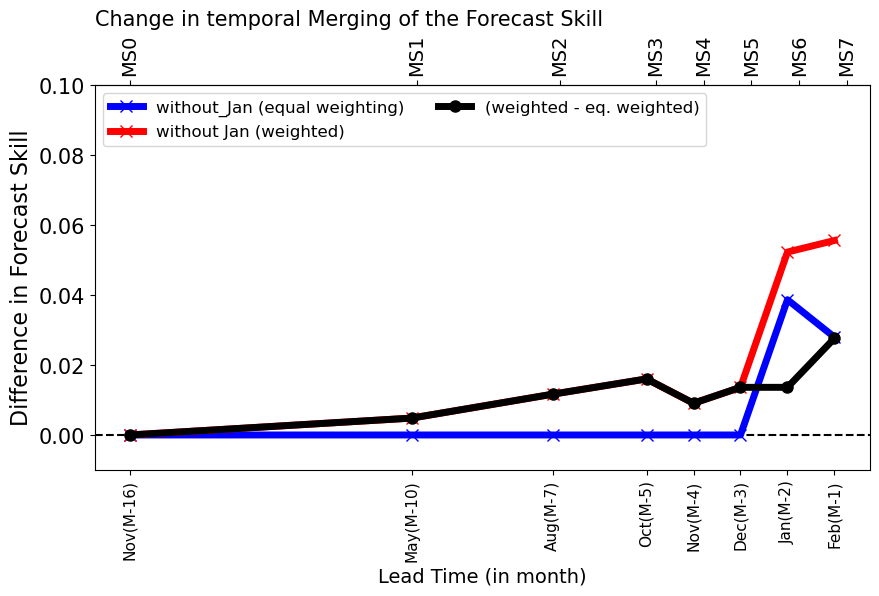

In [149]:
f,ax = plt.subplots(1,1,figsize=[10,5])
#ax2 = ax.twinx()

leadtime=np.arange(16)

ftz=14

ci=0.05
#ax2.set_ylim([0,300])

ax.set_ylim([-0.01,0.1])
ax.xaxis.set_tick_params(labelsize=11)
ax.yaxis.set_tick_params(labelsize=15)
#ax2.yaxis.set_tick_params(labelsize=15)

#ax2.bar(leadtime, merge_ens[:,0],color='gray',label='Ensemble size',linestyle='solid',width=0.4,alpha=0.5)

#ax.set_xticks(leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15],leadtime[16])

leadtime3=np.array([leadtime[0],leadtime[6],leadtime[9],leadtime[11],leadtime[12],leadtime[13],leadtime[14],leadtime[15]])

ax.set_xticks(leadtime3)

ax.set_xticklabels( ('Nov(M-16)', 'May(M-10)','Aug(M-7)','Oct(M-5)','Nov(M-4)','Dec(M-3)','Jan(M-2)','Feb(M-1)' ))

ax.tick_params(axis='x', labelrotation=90)




ax.plot(leadtime3,diff_withjan_withoutjan_eq,color='blue',label='without_Jan (equal weighting)',linestyle='solid',marker='x',markersize=8,linewidth=5,zorder=10)
ax.plot(leadtime3,diff_withjan_withoutjanold,color='red',label='without Jan (weighted)',linestyle='solid',marker='x',markersize=8,linewidth=5,zorder=10)
ax.plot(leadtime3,diff_withjan_withoutjan_new,color='black',label='(weighted - eq. weighted)',linestyle='solid',marker='o',markersize=8,linewidth=5,zorder=10)


ax.set_xlabel('Lead Time (in month)',fontsize=14)
ax.set_ylabel('Difference in Forecast Skill', fontsize=16)

#ax2.set_ylabel('Ensemble size', fontsize=16)
#ax.set_xlabel('Lead Time',fontsize=14)
#ax.set_ylabel('Skill', fontsize=16)

ax.axhline(0,linestyle='dashed',color='black')

#ax.fill_between(leadtime3,skillmerge_lb_15,skillmerge_ub_15,alpha=0.4,color='orange')
#ax.fill_between(np.arange(0,9,1),skill_rand15_lbnd,skill_rand15_ubnd,alpha=0.4,color='orange')#,label='shading95%')


ax.set_title('Change in temporal Merging of the Forecast Skill',fontsize=15,loc='left')
ax.legend(fontsize=12,loc='upper left',ncols=2)
#ax2.legend(fontsize=10,loc='upper right',ncols=2)


def deg2rad(x):
    return x- x * np.pi / 180 


def rad2deg(x):
    return x * 180 / np.pi 
   
secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))

#secax.set_xticks(ms2[:-1])

secax.set_xticks(ms2[:-1])
#secax.set_xticklabels(ax.get_xticks(), rotation=90)

secax.set_xticklabels(ax.get_xticks(), rotation=90)
#secax.set_xticklabels( ('MayY2','MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7','MS8' ))
secax.set_xticklabels( ('MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7' ))
secax.xaxis.set_tick_params(labelsize=14)



plt.savefig(dirfig+'FigureS6_Difference_jan_withoutJan_mergeskill_weighted.png',dpi=300,bbox_inches='tight')

In [169]:
skill_merged_march_Weighted=[0.24020275240184363,
 0.1781774546328009,
 0.30088340865330065,
 0.2844198649379014,
 0.17214942832119245,
 0.26701208293261053,
 0.26701208293261053,
 0.2496840716054104,
 0.6951859562036229]
#skill_merged_march_Weighted

In [183]:
skillmatrix_maap_n

#skillmerge



skillmatrix_maap_n1=[skillnov_y2.rvalue,skillmay.rvalue,skillaug.rvalue, skilloct.rvalue, skillnov.rvalue,skilldec.rvalue, skilljan.rvalue, skillfeb.rvalue, skillmar.rvalue]
skillmatrix_maap_n1


diff_add=np.array([wskillmerge])-np.array([skillmatrix_maap_n[1:9]])
diff_add


rdiff_add=np.round(diff_add, 2)

diff_add_15=np.array([wskillmerge])-np.array([skillmerge_eq_nojan])
diff_add_15
rdiff_add2=np.round(diff_add_15, 2)


#leadtime[1:10]

#np.round(diff_add, 2)


#rdiff_add[0,:]

#rdiff_add2

#diff_add

#rdiff_add2[0,:]

#rdiff_add[0,:]

In [184]:
#rdiff_add2[0,:]

In [168]:
#merge_ens

In [167]:
#skillmatrix_maap_n[1:9]

In [166]:
leadtime1=np.arange(22)
leadtime2=np.array([leadtime1[0],leadtime1[6],leadtime1[12],leadtime1[15],leadtime1[17],leadtime1[18],leadtime1[19],leadtime1[20],leadtime1[21]])
leadtime2



merge_ens[1,:]

ensize[1,:]

#leadtime2[1:10]

leadtime4=np.arange(16)


leadtime5=np.array([leadtime4[0],leadtime4[6],leadtime4[9],leadtime4[11],leadtime4[12],leadtime4[13],leadtime4[14],leadtime4[15]])
#leadtime5

/tmp/user/27683/ipykernel_2499359/4156030565.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticks(), rotation = 0)
/tmp/user/27683/ipykernel_2499359/4156030565.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticks(), rotation =90)
/tmp/user/27683/ipykernel_2499359/4156030565.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))
/tmp/user/27683/ipykernel_2499359/4156030565.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels

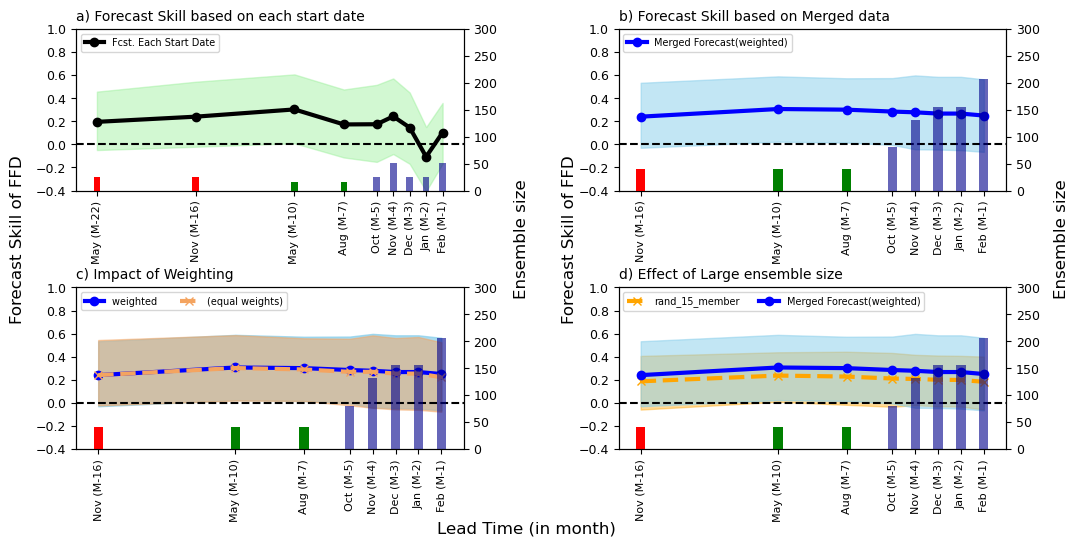

In [193]:
f,ax = plt.subplots(2,2,figsize=[12,6])

f.subplots_adjust(top=0.85,bottom=0.15, hspace=0.6, wspace=0.4)
ax=ax.ravel()

ax2 = ax[0].twinx()
ftz=14

ci=0.05
ax[0].set_xticklabels(ax[0].get_xticks(), rotation = 0)

ax2.set_ylim([0,300])
ax[0].set_ylim([-0.4, 1.0])
ax[0].set_xticklabels(ax[0].get_xticks(), rotation =90)

ax[0].yaxis.set_major_locator(MultipleLocator(0.2))

ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].yaxis.set_tick_params(labelsize=9)
ax2.yaxis.set_tick_params(labelsize=9)



ax2.bar(leadtime1[0],ensize[0,0],color='red',width=0.4)
ax2.bar(leadtime1[6],ensize[1,0],color='red',width=0.4)

ax2.bar(leadtime1[12],ensize[2,0],color='green',width=0.4)
ax2.bar(leadtime1[15],ensize[3,0],color='green',width=0.4)

ax2.bar(leadtime1[17],ensize[4,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime1[18],ensize[5,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime1[19],ensize[6,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime1[20],ensize[7,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime1[21],ensize[8,0],color='darkblue',width=0.4,alpha=0.6)
#ax2.bar(leadtime1[22],ensize[9,0],color='darkblue',width=0.4,alpha=0.6)



#ax[0].set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)','Mar (M-0)' ))
ax[0].set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))

ax[0].set_xticks(leadtime2)

ax[0].plot(leadtime2,skillmatrix_maap_n[:-1],color='black',label='Fcst. Each Start Date',linestyle='solid',marker='o',markersize=6,linewidth=3,zorder=10)

ax[0].fill_between(leadtime2,skill_lbnd_1[:-1],skill_upbnd_1[:-1],alpha=0.4,color='lightgreen')#,label='shading_95%')

ax[0].axhline(0,linestyle='dashed',color='black')

#ax[0].set_ylabel('Forecast Skill of FFD', fontsize=10)

ax[0].set_title('a) Forecast Skill based on each start date',fontsize=10,loc='left')

ax[0].legend(fontsize=7,loc='upper left',ncols=1)


######

ax2 = ax[1].twinx()

#leadtime=np.arange(9)

ftz=14

ci=0.05
ax2.set_ylim([0,300])
ax[1].set_ylim([-0.4, 1.0])

ax[1].yaxis.set_major_locator(MultipleLocator(0.2))

ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].yaxis.set_tick_params(labelsize=9)
ax2.yaxis.set_tick_params(labelsize=9)

ax[1].set_xticklabels(ax[1].get_xticks(), rotation =90)
#ax2.bar(leadtime[0],merge_ens[0,0],color='red',width=0.4)
ax2.bar(leadtime4[0],merge_ens[0,0],color='red',width=0.4)

ax2.bar(leadtime4[6],merge_ens[1,0],color='green',width=0.4)
ax2.bar(leadtime4[9],merge_ens[2,0],color='green',width=0.4)

ax2.bar(leadtime4[11],merge_ens[3,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[12],merge_ens[4,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[13],merge_ens[5,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[14],merge_ens[6, 0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[15],merge_ens[7,0],color='darkblue',width=0.4,alpha=0.6)

ax[1].set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))
ax[1].set_xticks(leadtime5)

#ax[1].set_ylabel('Forecast Skill of FFD', fontsize=10)


ax[1].plot(leadtime5,wskillmerge,color='blue',label='Merged Forecast(weighted)',linestyle='solid',marker='o',markersize=6,linewidth=3,zorder=10)
ax[1].fill_between(leadtime5,wlow_ci,whigh_ci,alpha=0.5,color='skyblue')#,label='shading95%')


def deg2rad(x):
    return x- x * np.pi / 180 


def rad2deg(x):
    return x * 180 / np.pi 


ax[1].set_title('b) Forecast Skill based on Merged data',fontsize=10,loc='left')

ax[1].axhline(0,linestyle='dashed',color='black')

ax[1].legend(fontsize=7,loc='upper left')
#ax2.legend(fontsize=5,loc='upper right',ncols=3)


##################################
ax2 = ax[2].twinx()



ftz=14

ci=0.05
ax2.set_ylim([0,300])
ax[2].xaxis.set_tick_params(labelsize=8)
ax[2].yaxis.set_tick_params(labelsize=9)
ax2.yaxis.set_tick_params(labelsize=9)

#ax[2].xaxis.set_tick_params(labelsize=11)
#ax[2].yaxis.set_tick_params(labelsize=15)
#ax2.yaxis.set_tick_params(labelsize=15)


ax2.bar(leadtime4[0],merge_ens[0,0],color='red',width=0.4)

ax2.bar(leadtime4[6],merge_ens[1,0],color='green',width=0.4)
ax2.bar(leadtime4[9],merge_ens[2,0],color='green',width=0.4)

ax2.bar(leadtime4[11],merge_ens[3,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[12],merge_ens[4,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[13],merge_ens[5,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[14],merge_ens[6, 0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[15],merge_ens[7,0],color='darkblue',width=0.4,alpha=0.6)
#ax2.bar(leadtime4[16],merge_ens[8,0],color='darkblue',width=0.4,alpha=0.6)

ax[2].set_xticks(leadtime5)

ax[2].set_xticklabels(ax[2].get_xticks(), rotation =90)

ax[2].set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))


#ax[2].set_ylabel('Forecast Skill of FFD', fontsize=10)


#ax2.set_ylim([-0.25, 0.85])
ax[2].set_ylim([-0.4, 1.0])
ax[2].yaxis.set_major_locator(MultipleLocator(0.2))



ax[2].plot(leadtime5,wskillmerge,color='blue',label='weighted ',linestyle='solid',marker='o',markersize=6,linewidth=3,zorder=10)
ax[2].fill_between(leadtime5,wlow_ci,whigh_ci,alpha=0.7,color='skyblue')#,label='shading95%')


ax[2].plot(leadtime5,skillmerge_eq_nojan,color='sandybrown',label='(equal weights)',linestyle='dashed',marker='x',markersize=6,linewidth=3,zorder=10)
ax[2].fill_between(leadtime5,trendlow_ci,trendhigh_ci,alpha=0.5,color='sandybrown')#,label='shading95%')


#ax[2].plot(leadtime5,oldskillmerge_eq,color='skyblue',label='Merged Forecast (with Jan)',linestyle='dashed',marker='o',markersize=8,linewidth=5)


ax[2].set_title('c) Impact of Weighting',fontsize=10,loc='left')

ax[2].axhline(0,linestyle='dashed',color='black')


ax[2].legend(fontsize=7,loc='upper left',ncols=3)


########################
ax2 = ax[3].twinx()
#ax2 = ax[3].twiny()
#leadtime=np.arange(9)
ftz=14

ci=0.05
ax2.set_ylim([0,300])

#ax[3].set_ylim([-5, 45])
ax[3].set_ylim([-0.4, 1.0])
ax[3].yaxis.set_major_locator(MultipleLocator(0.2))

ax[3].xaxis.set_tick_params(labelsize=8)
ax[3].yaxis.set_tick_params(labelsize=9)
ax2.yaxis.set_tick_params(labelsize=9)

ax2.bar(leadtime4[0],merge_ens[0,0],color='red',width=0.4)

ax2.bar(leadtime4[6],merge_ens[1,0],color='green',width=0.4)
ax2.bar(leadtime4[9],merge_ens[2,0],color='green',width=0.4)

ax2.bar(leadtime4[11],merge_ens[3,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[12],merge_ens[4,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[13],merge_ens[5,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[14],merge_ens[6, 0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime4[15],merge_ens[7,0],color='darkblue',width=0.4,alpha=0.6)
#ax2.bar(leadtime4[16],merge_ens[8,0],color='darkblue',width=0.4,alpha=0.6)

#ax2.bar(leadtime[0], merge_ens[0,0],color='maroon',label='Ensemble size',linestyle='solid',width=0.4)


ax[3].set_xticks(leadtime5)
ax[3].set_xticklabels(ax[3].get_xticks(), rotation=90)

ax[3].set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))


ax[3].plot(leadtime5,skillsup_15_wmean,color='orange',linestyle='dashed',marker='x',markersize=6,label='rand_15_member',linewidth=3,zorder=10)
ax[3].fill_between(leadtime5,skillmerge_wlb_15,skillmerge_wub_15,alpha=0.4,color='orange')#,label='shading95%')

#merged forecast
ax[3].plot(leadtime5,wskillmerge, color='blue',label='Merged Forecast(weighted)',linestyle='solid',marker='o',markersize=6,linewidth=3,zorder=10)
ax[3].fill_between(leadtime5,wlow_ci,whigh_ci,alpha=0.5,color='skyblue')#,label='shading95%')



ax[3].legend(fontsize=7,loc='upper left',ncols=3)
ax[3].axhline(0,linestyle='dashed',color='black')


ax[3].set_title('d) Effect of Large ensemble size',fontsize=10, loc='left')


f.text(0.94,0.5, 'Ensemble size', rotation='vertical',fontsize=12,va='center')
f.text(0.49,0.5, 'Ensemble size', rotation='vertical',fontsize=12,va='center')
f.text(0.07,0.5, 'Forecast Skill of FFD', rotation='vertical',fontsize=12,va='center')
f.text(0.53,0.5, 'Forecast Skill of FFD', rotation='vertical',fontsize=12,va='center')
f.text(0.5,0.01, 'Lead Time (in month)', fontsize=12,ha='center')


plt.savefig(dirfig+'revised_Fig4_article_final_withWeights_comparison.png',dpi=300,bbox_inches='tight')

In [151]:
#wlow_ci,whigh_ci

In [174]:
diff_skill_weight_noweight=np.array([wskillmerge]) - np.array([skillmerge_eq_nojan])
diff_skill_weight_noweight*100


diff_skill_weight_15mem=np.array([wskillmerge]) - np.array([skillsup_15_wmean])
diff_skill_weight_15mem*100

diff_skill_weight=np.array([skillmerge_eq_nojan]) - np.array([oldskillmerge_eq])
diff_skill_weight*100 

diff_skill_weight_old=np.array([wskillmerge]) - np.array([oldskillmerge_eq])
diff_skill_weight_old 

diff_merge_each=np.array([wskillmerge]) - np.array(skillmatrix_maap_n[1:9])
diff_merge_each


diff_skill_eqweight_withoutJan=np.array([skillmerge_eq_nojan]) -np.array(skillmatrix_maap_n[1:9])
#diff_skill_eqweight_withoutJan

In [173]:
diff_oldmerge_each=np.array([oldskillmerge_eq])-np.array(skillmatrix_maap_n[1:9])
#diff_oldmerge_each

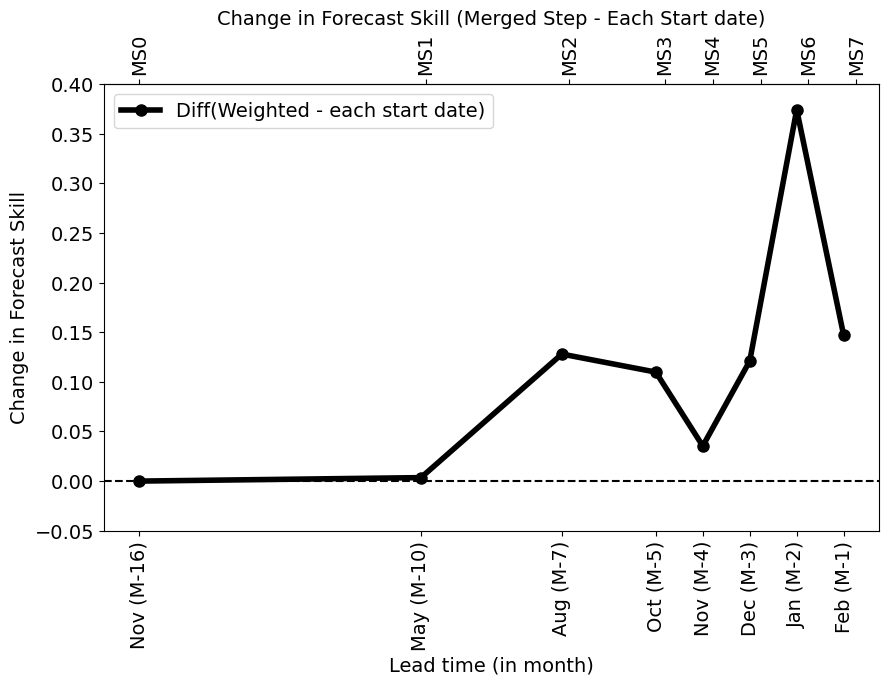

In [191]:
f,ax = plt.subplots(1,1,figsize=[10,5.8])

#ax2 = ax.twinx()



ci=0.05
#ax2.set_ylim([0,300])

#ax[3].set_ylim([-5, 45])
ax.set_ylim([-0.05, 0.4])

ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)


ax.set_xticks(leadtime5)
ax.set_xticklabels(ax.get_xticks(), rotation=90)

ax.set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))


ax.set_ylabel('Change in Forecast Skill', fontsize=14)
ax.set_xlabel('Lead time (in month)', fontsize=14)
ax.plot(leadtime5,diff_merge_each[0,:],color='black',label='Diff(Weighted - each start date)',linestyle='solid',marker='o',markersize=8,linewidth=4,zorder=10)
#ax.plot(leadtime5,diff_oldmerge_each[0,:],color='grey',label='Diff(Eq.weights(Included Jan) - each start date)',linestyle='dashed',marker='x',markersize=8,linewidth=4,zorder=10)

#ax.plot(leadtime5, diff_skill_eqweight_withoutJan[0,:],color='red',label='Diff(Eq.weights(excl. Jan) - each start date)',linestyle='dashed',marker='x',markersize=8,linewidth=2,zorder=10)

ax.axhline(0,linestyle='dashed',color='black')

#ax.plot(leadtime5[:-1],diff_merge_each,color='gray',linestyle='dashed',marker='x',markersize=6,label='Diff(Merged Fcst - Fcst based on 15 ensemble members)',linewidth=3,zorder=10)

ax.legend(fontsize=14,loc='upper left',ncols=1)


ax.set_title('Change in Forecast Skill (Merged Step - Each Start date)',fontsize=14, loc='center')


def deg2rad(x):
    return x- x * np.pi / 180 


def rad2deg(x):
    return x * 180 / np.pi 
   
secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))


secax.set_xticks(ms2[:-1])

secax.set_xticklabels(ax.get_xticks(), rotation=90)
secax.set_xticklabels( ('MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7' ))
secax.xaxis.set_tick_params(labelsize=14)


plt.savefig(dirfig+'FigureS5_change_skill_merged_eachdate.png',dpi=300,bbox_inches='tight')

# E-OBS vs ERA5 plot

In [188]:
#leadtime2

leadtime11=np.arange(23)
leadtime22=np.array([leadtime11[0],leadtime11[6],leadtime11[12],leadtime11[15],leadtime11[17],leadtime11[18],leadtime11[19],leadtime11[20],leadtime11[21], leadtime11[22]] )
leadtime22

array([ 0,  6, 12, 15, 17, 18, 19, 20, 21, 22])

In [189]:
ensize[9,0], leadtime11[22]

(25, 22)

/tmp/user/27683/ipykernel_2499359/2020360576.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation = 0)
/tmp/user/27683/ipykernel_2499359/2020360576.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation =90)
/tmp/user/27683/ipykernel_2499359/2020360576.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)','Mar (M-0)' ))


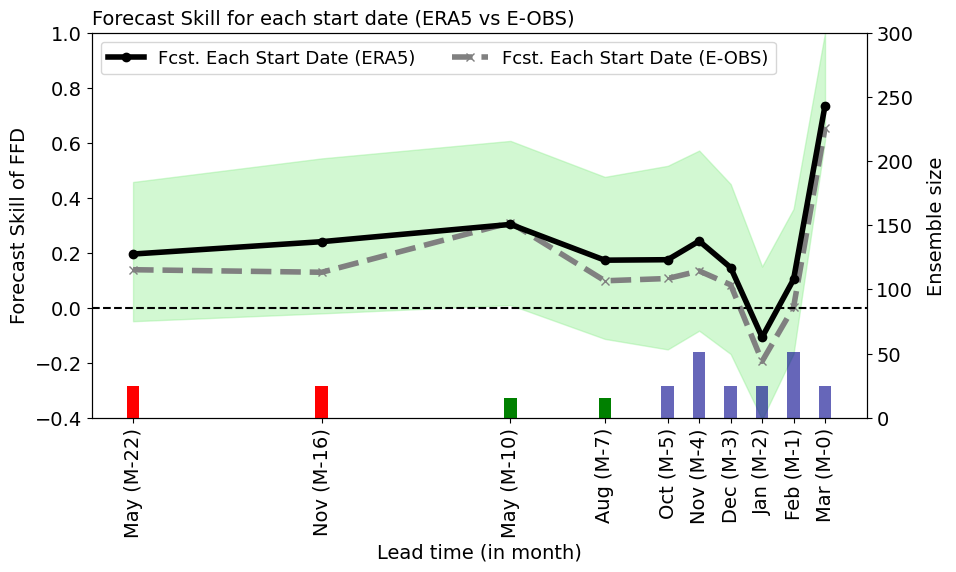

In [190]:
f,ax = plt.subplots(1,1,figsize=[10,5])

#ax2=ax.ravel()

ax2 = ax.twinx()
ftz=14

ci=0.05
ax.set_xticklabels(ax.get_xticks(), rotation = 0)

ax2.set_ylim([0,300])
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax2.yaxis.set_tick_params(labelsize=14)
ax.set_ylim([-0.4, 1])
ax.set_xticklabels(ax.get_xticks(), rotation =90)


ax2.bar(leadtime11[0],ensize[0,0],color='red',width=0.4)
ax2.bar(leadtime11[6],ensize[1,0],color='red',width=0.4)

ax2.bar(leadtime11[12],ensize[2,0],color='green',width=0.4)
ax2.bar(leadtime11[15],ensize[3,0],color='green',width=0.4)

ax2.bar(leadtime11[17],ensize[4,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime11[18],ensize[5,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime11[19],ensize[6,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime11[20],ensize[7,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime11[21],ensize[8,0],color='darkblue',width=0.4,alpha=0.6)
ax2.bar(leadtime11[22],ensize[9,0],color='darkblue',width=0.4,alpha=0.6)

ax.set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)','Mar (M-0)' ))

ax.set_xticks(leadtime22)

ax.plot(leadtime22,skillmatrix_maap_n,color='black',label='Fcst. Each Start Date (ERA5)',linestyle='solid',marker='o',markersize=6,linewidth=4,zorder=10)
ax.fill_between(leadtime22,skill_lbnd_1,skill_upbnd_1,alpha=0.4,color='lightgreen')#,label='shading_95%')

ax.plot(leadtime22,skillmatrix_maap_eobs,color='grey',label='Fcst. Each Start Date (E-OBS)',linestyle='dashed',marker='x',markersize=6,linewidth=4)

ax.axhline(0,linestyle='dashed',color='black')

#ax[0].set_xlabel('Lead Time',fontsize=12)
ax2.set_ylabel('Ensemble size', fontsize=14,labelpad=10)
ax.set_ylabel('Forecast Skill of FFD', fontsize=14)
ax.set_xlabel('Lead time (in month)', fontsize=14)

ax.set_title('Forecast Skill for each start date (ERA5 vs E-OBS)',fontsize=14,loc='left')

#ax2.legend(fontsize=5,loc='upper right',ncols=3)
ax.legend(fontsize=13,loc='upper left',ncols=2)

plt.savefig(dirfig+'FigureS4_forecastskill_eobs_era5.png',dpi=300,bbox_inches='tight')

# Skill (trend vs detrend)

In [211]:
# these values are calculated separately and plotted here with trends. Values are from may-y2 to March forecast. For plotting exlcuded May-Year2 and March.

In [203]:
dtd_skillmatrix_maap=[-0.04164009235682897,
  -0.0002129867862095125,
  0.17382642945449334,
  -0.020101689631701447,
  -0.09559935270954156,
  0.01324364233732922,
  -0.08508679828810273,
  -0.3061352376098512,
  -0.20085517768166028,
  0.7045981241099071]

In [204]:
skill_rand_lbnd_dtd_2=[-0.31, -0.26, -0.11, -0.37, -0.38, -0.29, -0.36, -0.57, -0.38, 0.56]

In [205]:
skill_rand_upbnd_dtd_2= [0.26, 0.29, 0.46, 0.34, 0.18, 0.27, 0.19, -0.08, -0.01, 1.0]

Text(0.0, 1.0, 'Forecast Skill (Detrend vs Trend)')

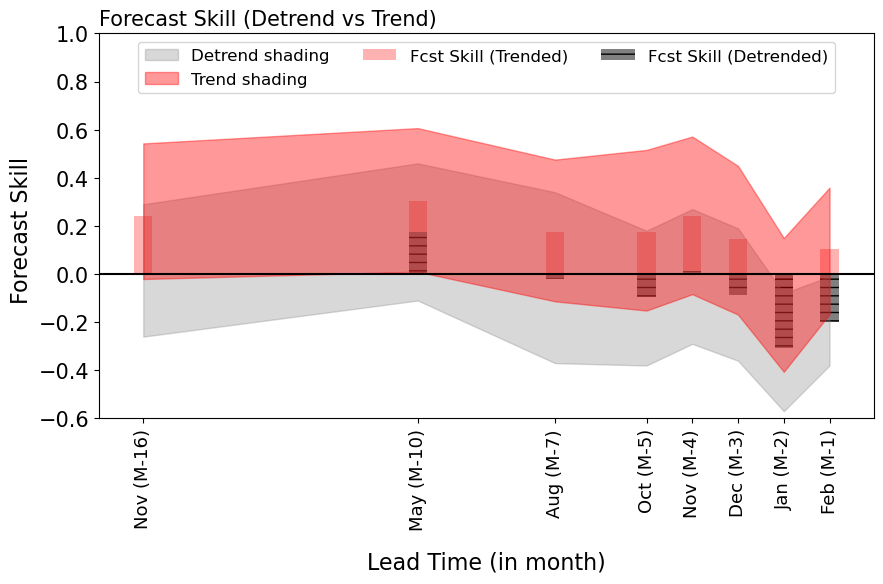

In [210]:
f,ax = plt.subplots(1,1,figsize=[10,5])


leadtime4=np.arange(17)

#ax.set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)','Mar (M-0)' ))

leadtime5=np.array([leadtime4[0],leadtime4[6],leadtime4[9],leadtime4[11],leadtime4[12],leadtime4[13],leadtime4[14],leadtime4[15],leadtime4[16]])
leadtime5


ax.set_xticks(leadtime5[:-1])
ax.set_xticklabels(ax.get_xticks(), rotation=90)

ax.set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))

ftz=12
ci=0.05

ax.set_ylim([-0.6, 1.0])
ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_tick_params(labelsize=13)

#ax.bar(month1, skillmatrix_maap,color='red',label='FFD_Skill_Trend',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[0], skillmatrix_maap_n[1],color='red',label='Fcst Skill (Trended)',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[0], dtd_skillmatrix_maap[1],color='gray',label='Fcst Skill (Detrended)',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[6], skillmatrix_maap_n[2],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[6], dtd_skillmatrix_maap[2],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[9], skillmatrix_maap_n[3],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[9], dtd_skillmatrix_maap[3],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[11], skillmatrix_maap_n[4],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[11], dtd_skillmatrix_maap[4],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[12], skillmatrix_maap_n[5],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[12], dtd_skillmatrix_maap[5],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[13], skillmatrix_maap_n[6],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[13], dtd_skillmatrix_maap[6],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[14], skillmatrix_maap_n[7],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[14], dtd_skillmatrix_maap[7],color='gray',linestyle='solid', width=0.4,hatch=['--'])

ax.bar(leadtime4[15], skillmatrix_maap_n[8],color='red',linestyle='solid', width=0.4,alpha=0.3)
ax.bar(leadtime4[15], dtd_skillmatrix_maap[8],color='gray',linestyle='solid', width=0.4,hatch=['--'])


#ax.bar(leadtime4[16], skillmatrix_maap_n[9],color='red',linestyle='solid', width=0.4,alpha=0.3)
#ax.bar(leadtime4[16], dtd_skillmatrix_maap[9],color='red',linestyle='solid', width=0.4,hatch=['--'])

#ax.set_xticks(leadtime)

ax.fill_between(leadtime5[:-1],skill_rand_lbnd_dtd_2[1:9],skill_rand_upbnd_dtd_2[1:9],alpha=0.3,color='gray',label='Detrend shading')
ax.fill_between(leadtime5[:-1],skill_lbnd_1[1:9],skill_upbnd_1[1:9],alpha=0.4,color='red',label='Trend shading')#,label='shading_95%')


ax.yaxis.set_tick_params(labelsize=15)
ax.xaxis.set_tick_params(labelsize=13)

ax.set_ylabel('Forecast Skill ', fontsize=16)
ax.set_xlabel('Lead Time (in month)',fontsize=16,labelpad=15)
#ax.axhline(0.31,linestyle='dashed',color='gray',label='95% Sign. level')
ax.axhline(0,linestyle='solid',color='black')
ax.legend(fontsize=12,loc='upper center',ncols=3)

ax.set_title('Forecast Skill (Detrend vs Trend)',fontsize=15,loc='left')

#plt.savefig(dirfig+"Figure5_revised_trend_vs_Detrend.png",dpi=300,bbox_inches = "tight")#